In [ ]:
#import libraries
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:
#Load Dataset
import tensorflow as tf
import tensorflow_datasets as tfds

(dataset_train, dataset_val), dataset_info = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:]'],
    with_info=True,
    as_supervised=True,
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.1JXJP0_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


In [ ]:
#Resize + Normalize Images
IMG_SIZE = 150

def format_image(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0
    return image, label

dataset_train = dataset_train.map(format_image)
dataset_val = dataset_val.map(format_image)

dataset_train = dataset_train.batch(32)
dataset_val = dataset_val.batch(32)

In [ ]:
#Build CNN Model
model = models.Sequential()

# Convolution Layer 1
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)))
model.add(layers.MaxPooling2D(2,2))

# Convolution Layer 2
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

# Convolution Layer 3
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

# Flatten
model.add(layers.Flatten())

# Dense Layer
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dropout(0.5))

# Output Layer
model.add(layers.Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
#Train Model
history = model.fit(
    dataset_train,
    validation_data=dataset_val,
    epochs=5
)

Epoch 1/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 1082s 2s/step - accuracy: 0.5941 - loss: 0.6685 - val_accuracy: 0.7476 - val_loss: 0.5299
Epoch 2/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 1061s 2s/step - accuracy: 0.7572 - loss: 0.5010 - val_accuracy: 0.7732 - val_loss: 0.4727
Epoch 3/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 1059s 2s/step - accuracy: 0.8116 - loss: 0.4179 - val_accuracy: 0.8003 - val_loss: 0.4417
Epoch 4/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 1063s 2s/step - accuracy: 0.8532 - loss: 0.3362 - val_accuracy: 0.8009 - val_loss: 0.4699
Epoch 5/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 1054s 2s/step - accuracy: 0.8971 - loss: 0.2458 - val_accuracy: 0.8156 - val_loss: 0.4955


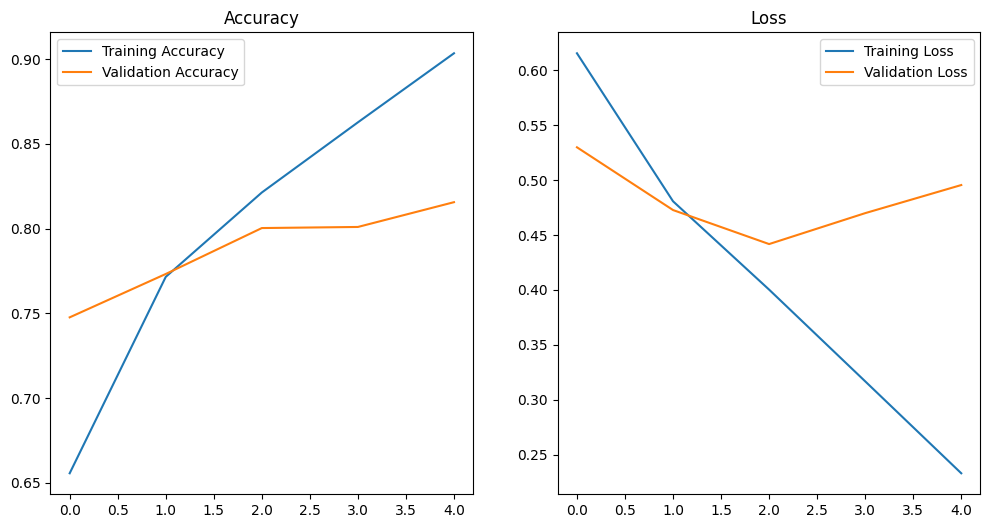

In [ ]:
#Plot Accuracy & Loss Graph
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(5)

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()

In [ ]:
#Evaluate Model
loss, accuracy = model.evaluate(dataset_val)
print("Validation Accuracy:", accuracy)

146/146 ━━━━━━━━━━━━━━━━━━━━ 70s 477ms/step - accuracy: 0.8139 - loss: 0.5252
Validation Accuracy: 0.8155632019042969


In [ ]:
#Save Model
model.save("cat_dog_model.h5")

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 3af0d5bda679b490c594ce54c286300e.jpg to 3af0d5bda679b490c594ce54c286300e.jpg


In [ ]:
#Predict on New Image
from tensorflow.keras.preprocessing import image

img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(150,150))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Dog ")
else:
    print("Cat ")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
Dog 
